In [12]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import jaxdem as jd
import os
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm

from jaxdem.analysis import evaluate_binned, LagBinsPseudoLog, LagBinsLinear, LagBinsExact, msd_kernel
from jaxdem.analysis.kernels import isf_self_kvecs_kernel, isf_self_isotropic_kernel

def load_arrs(path):
    with h5py.File(path, 'r') as f:
        return {name: f[name][()] for name in f.keys()}

# GA

In [2]:
root = '/Users/marshallmccraw/Projects/yale/data/s-26/grant/server-data/ga-data'
data = load_arrs(os.path.join(root, 'traj', 'data.h5'))
state = jd.utils.h5.load(os.path.join(root, 'init', 'state.h5'))
cids, nv = np.unique(state.clump_ID, return_counts=True)

In [3]:
# repeat correlations:
# small, large: msd, isf
# avg: msd, isf
# remove drift

In [4]:
pos = data['pos'][:, nv == min(nv)]

step_ids = jd.utils.make_save_steps_pseudolog(
    num_steps=10_000_000,
    reset_save_decade=100_000,
    min_save_decade=100,
    decade=10,
    include_step0=True,
)
bins = LagBinsPseudoLog(
    pos.shape[0],
    dt_min=1,
    dt_max=int(step_ids[-1] - step_ids[0]),
    timestep=step_ids,
)

tau_steps = bins.values()
t = tau_steps * float(1e-2)

msd_res = evaluate_binned(msd_kernel, {"pos": pos}, bins)
msd = np.asarray(msd_res.mean)

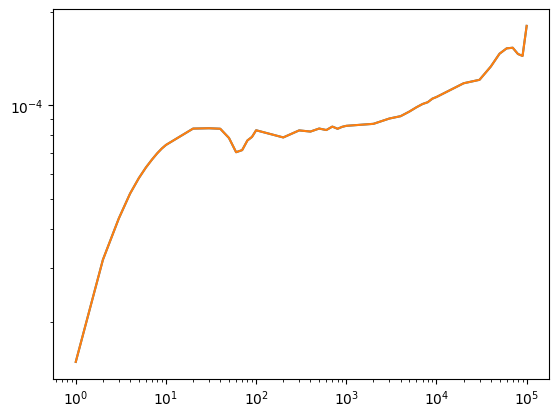

In [5]:
plt.plot(t, msd)
plt.plot(data['t'], data['msd_small'])
plt.xscale('log')
plt.yscale('log')

In [6]:

def make_kvecs_ring(k, M=16):
    """M evenly-spaced wave vectors on a 2D ring of radius k."""
    angles = np.linspace(0, 2 * np.pi, M, endpoint=False)
    return np.column_stack([k * np.cos(angles), k * np.sin(angles)])

def make_kvecs_shell(k, M=32):
    """M approximately uniform points on a 3D shell of radius k."""
    indices = np.arange(M, dtype=np.float64)
    golden = (1 + np.sqrt(5)) / 2
    theta = np.arccos(1 - 2 * (indices + 0.5) / M)
    phi = 2 * np.pi * indices / golden
    return k * np.column_stack([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ])

In [13]:
diam = 1.0
pos = data['pos'][:, nv == min(nv)]

k_value = 2 * np.pi / diam
kvecs = make_kvecs_ring(k_value, M=32)  # shape (32, 2)

isf_res = evaluate_binned(
    isf_self_kvecs_kernel,
    {"pos": pos},
    bins,
    kernel_kwargs={"kvecs": kvecs},
)
# isf_res.mean has shape (B, K) where K=32
# Average over the K directions to get the isotropic Fs(k, t):
isf = np.mean(np.asarray(isf_res.mean), axis=-1)  # (B,)


isf_res = evaluate_binned(isf_self_isotropic_kernel, {"pos": pos}, bins, kernel_kwargs={"k": k_value})
isf_2 = np.array(isf_res.mean)

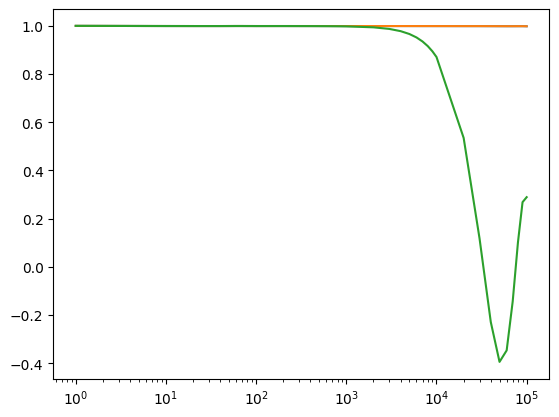

In [14]:
plt.plot(t, isf)
plt.plot(t, isf_2)
plt.plot(data['t'], data['isf_small'])
plt.xscale('log')

# DP

In [8]:
root = '/Users/marshallmccraw/Projects/yale/data/s-26/grant/server-data/dp-data'
data = load_arrs(os.path.join(root, 'traj', 'data.h5'))


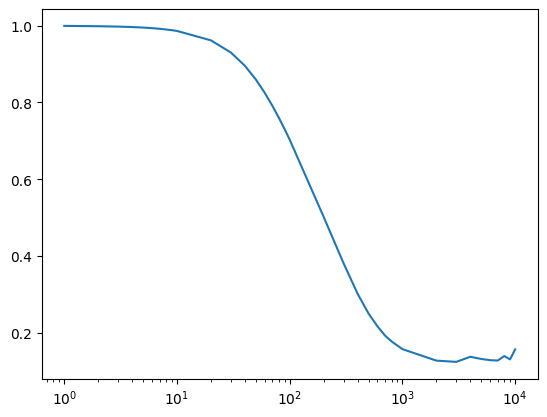

In [15]:
plt.plot(data['t'], data['isf_vertex_small'])
plt.xscale('log')